In [7]:
import os
print(os.getcwd())


/Users/ttanvitummapudi/Downloads


In [9]:
import pandas as pd
import numpy as np

file = [
    "/Users/ttanvitummapudi/Downloads/CICIDSMAINDATASET/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "/Users/ttanvitummapudi/Downloads/CICIDSMAINDATASET/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "/Users/ttanvitummapudi/Downloads/CICIDSMAINDATASET/Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "/Users/ttanvitummapudi/Downloads/CICIDSMAINDATASET/Monday-WorkingHours.pcap_ISCX.csv",
    "/Users/ttanvitummapudi/Downloads/CICIDSMAINDATASET/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "/Users/ttanvitummapudi/Downloads/CICIDSMAINDATASET/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "/Users/ttanvitummapudi/Downloads/CICIDSMAINDATASET/Tuesday-WorkingHours.pcap_ISCX.csv",
    "/Users/ttanvitummapudi/Downloads/CICIDSMAINDATASET/Wednesday-workingHours.pcap_ISCX.csv"
]

df_list = []
total_rows = 0
for f in file:
    temp = pd.read_csv(f)
    print(f"{f} → {temp.shape[0]} rows")
    df_list.append(temp)
    total_rows += temp.shape[0]

df = pd.concat(df_list, ignore_index=True)
print("combined rows:", df.shape[0])


/Users/ttanvitummapudi/Downloads/CICIDSMAINDATASET/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv → 225745 rows
/Users/ttanvitummapudi/Downloads/CICIDSMAINDATASET/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv → 286467 rows
/Users/ttanvitummapudi/Downloads/CICIDSMAINDATASET/Friday-WorkingHours-Morning.pcap_ISCX.csv → 191033 rows
/Users/ttanvitummapudi/Downloads/CICIDSMAINDATASET/Monday-WorkingHours.pcap_ISCX.csv → 529918 rows
/Users/ttanvitummapudi/Downloads/CICIDSMAINDATASET/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv → 288602 rows
/Users/ttanvitummapudi/Downloads/CICIDSMAINDATASET/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv → 170366 rows
/Users/ttanvitummapudi/Downloads/CICIDSMAINDATASET/Tuesday-WorkingHours.pcap_ISCX.csv → 445909 rows
/Users/ttanvitummapudi/Downloads/CICIDSMAINDATASET/Wednesday-workingHours.pcap_ISCX.csv → 692703 rows
combined rows: 2830743


In [10]:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("-", "_").str.replace(":", "_")
print("Cleaned columns")


Cleaned columns


In [11]:

df["Label"] = df["Label"].astype(str)

df["Label"] = df["Label"].str.replace("�", "", regex=False)

df["Label"] = df["Label"].str.replace(r"\s+", " ", regex=True).str.strip()

df["Label"] = df["Label"].replace({
    "Web Attack Brute Force": "Web Attack - Brute Force",
    "Web Attack Sql Injection": "Web Attack - SQL Injection",
    "Web Attack XSS": "Web Attack - XSS",
    "Web Attack: Brute Force": "Web Attack - Brute Force",
    "Web Attack: Sql Injection": "Web Attack - SQL Injection",
    "Web Attack: XSS": "Web Attack - XSS",
    "Web Attack  Brute Force": "Web Attack - Brute Force",
    "Web Attack  Sql Injection": "Web Attack - SQL Injection",
    "Web Attack  XSS": "Web Attack - XSS",
})

print("Cleaned labels:", sorted(df["Label"].unique()))


Cleaned labels: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - SQL Injection', 'Web Attack - XSS']


In [12]:
df["Label"] = df["Label"].astype(str).str.strip()

df["Label"] = df["Label"].replace({
    "Web Attack: XSS": "Web Attack - XSS",
    "Web Attack: Sql Injection": "Web Attack - SQL Injection",
    "Web Attack: Brute Force": "Web Attack - Brute Force"
})

print("\nLabels:", df["Label"].unique())



Labels: ['BENIGN' 'DDoS' 'PortScan' 'Bot' 'Infiltration'
 'Web Attack - Brute Force' 'Web Attack - XSS'
 'Web Attack - SQL Injection' 'FTP-Patator' 'SSH-Patator' 'DoS slowloris'
 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye' 'Heartbleed']


In [13]:
X = df.drop("Label", axis=1)
y = df["Label"]

X = X.apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)
print(X.shape)


(2830743, 78)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)


Scaled shape: (2830743, 78)


In [15]:
from sklearn.preprocessing import LabelEncoder
import json

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
label_map = {int(i): cls for i, cls in enumerate(label_encoder.classes_)}
print(label_map)

with open("cicids_label_map.json", "w") as f:
    json.dump(label_map, f)

print("Saved JSON.")


{0: 'BENIGN', 1: 'Bot', 2: 'DDoS', 3: 'DoS GoldenEye', 4: 'DoS Hulk', 5: 'DoS Slowhttptest', 6: 'DoS slowloris', 7: 'FTP-Patator', 8: 'Heartbleed', 9: 'Infiltration', 10: 'PortScan', 11: 'SSH-Patator', 12: 'Web Attack - Brute Force', 13: 'Web Attack - SQL Injection', 14: 'Web Attack - XSS'}
Saved JSON.


In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_dim = X_scaled.shape[1]
embedding_dim = 64

embedding_model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(embedding_dim, activation='relu')
], name="cicids_embedding_model")

embedding_model.summary()


Model: "cicids_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,368 (71.75 KB)

 Trainable params: 18,368 (71.75 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
batch_size = 50000
all_embeddings = []

for i in range(0, X_scaled.shape[0], batch_size):
    batch = X_scaled[i:i+batch_size]
    emb = embedding_model.predict(batch, verbose=1)
    all_embeddings.append(emb)

embeddings = np.vstack(all_embeddings)
print("final embedding shape:", embeddings.shape)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 233us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 226us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 226us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 222us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 222us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 225us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 226us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 227us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 222us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 221us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 224us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 237us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 224us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 221us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 220us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 224us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 224us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 220us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 222us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 225us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 225us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 220us/step
1563/1563 

In [18]:
print(type(embeddings))
print(embeddings.dtype if isinstance(embeddings, np.ndarray) else "not ndarray")

embeddings = np.asarray(embeddings, dtype=np.float32)

print("Embeddings dtype:", embeddings.dtype)
print("Embeddings shape:", embeddings.shape)


<class 'numpy.ndarray'>
float32
Embeddings dtype: float32
Embeddings shape: (2830743, 64)


In [19]:
df["Label"] = df["Label"].astype(str).str.strip()

df["Label"] = df["Label"].replace({
    "Web Attack  Brute Force": "Web Attack - Brute Force",
    "Web Attack  Sql Injection": "Web Attack - SQL Injection",
    "Web Attack  XSS": "Web Attack - XSS",
    "Web Attack: Brute Force": "Web Attack - Brute Force",
    "Web Attack: Sql Injection": "Web Attack - SQL Injection",
    "Web Attack: XSS": "Web Attack - XSS"
})

print("Cleaned labels:", df["Label"].unique())

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Label"])

class_names = list(label_encoder.classes_)
print("Classes:", class_names)

base_risk_by_label = {
    "BENIGN": 1,
    "Bot": 8,
    "DDoS": 9,
    "DoS GoldenEye": 8,
    "DoS Hulk": 8,
    "DoS Slowhttptest": 7,
    "DoS slowloris": 7,
    "FTP-Patator": 7,
    "Heartbleed": 10,
    "Infiltration": 10,
    "PortScan": 6,
    "SSH-Patator": 7,
    "Web Attack - Brute Force": 8,
    "Web Attack - SQL Injection": 10,
    "Web Attack - XSS": 7,
}

base_risk_by_index = {
    idx: base_risk_by_label[name]
    for idx, name in enumerate(class_names)
}

print("risk by index:", base_risk_by_index)


Cleaned labels: ['BENIGN' 'DDoS' 'PortScan' 'Bot' 'Infiltration'
 'Web Attack - Brute Force' 'Web Attack - XSS'
 'Web Attack - SQL Injection' 'FTP-Patator' 'SSH-Patator' 'DoS slowloris'
 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye' 'Heartbleed']
Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - SQL Injection', 'Web Attack - XSS']
risk by index: {0: 1, 1: 8, 2: 9, 3: 8, 4: 8, 5: 7, 6: 7, 7: 7, 8: 10, 9: 10, 10: 6, 11: 7, 12: 8, 13: 10, 14: 7}


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1981520, 64)
Test shape: (849223, 64)


In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = len(np.unique(y))

classifier = models.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = classifier.fit(
    X_train, y_train,
    batch_size=4096,
    epochs=10,
    validation_split=0.3
)


Epoch 1/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8283 - loss: 0.9652 - val_accuracy: 0.9494 - val_loss: 0.1803
Epoch 2/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9529 - loss: 0.1591 - val_accuracy: 0.9604 - val_loss: 0.1197
Epoch 3/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9606 - loss: 0.1156 - val_accuracy: 0.9640 - val_loss: 0.1002
Epoch 4/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9645 - loss: 0.0978 - val_accuracy: 0.9666 - val_loss: 0.0871
Epoch 5/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9665 - loss: 0.0855 - val_accuracy: 0.9683 - val_loss: 0.0795
Epoch 6/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9685 - loss: 0.0774 - val_accuracy: 0.9718 - val_loss: 0.0717
Epoch 7/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9714 - loss: 0.0712 - val_accuracy: 0.9716 - val_loss: 0.0667
Epoch 8/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9727 - loss: 0.0660 - val_accuracy: 0.

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = classifier.predict(X_test).argmax(axis=1)

print(classification_report(y_test, y_pred))


26539/26539 ━━━━━━━━━━━━━━━━━━━━ 6s 212us/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.98    681929
           1       1.00      0.01      0.01       590
           2       1.00      0.97      0.98     38408
           3       0.97      0.90      0.93      3088
           4       0.99      0.89      0.94     69322
           5       0.86      0.90      0.88      1650
           6       0.95      0.91      0.93      1739
           7       0.98      0.71      0.83      2381
           8       0.00      0.00      0.00         3
           9       0.18      0.18      0.18        11
          10       0.88      0.94      0.91     47679
          11       0.96      0.73      0.83      1769
          12       0.00      0.00      0.00       452
          13       0.00      0.00      0.00         6
          14       0.00      0.00      0.00       196

    accuracy                           0.97    849223
   macro avg       0.65      0.54

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
classifier.save("cicids_classifier.keras")
classifier.save("cicids_classifier.h5")

converter = tf.lite.TFLiteConverter.from_keras_model(classifier)
tflite_model = converter.convert()

with open("cicids_classifier.tflite", "wb") as f:
    f.write(tflite_model)

print(" saving Tensorflow Lite model")


INFO:tensorflow:Assets written to: /var/folders/11/r1pjvvbs5czcqcw2cfyrh1cr0000gn/T/tmps40y355i/assets


INFO:tensorflow:Assets written to: /var/folders/11/r1pjvvbs5czcqcw2cfyrh1cr0000gn/T/tmps40y355i/assets


Saved artifact at '/var/folders/11/r1pjvvbs5czcqcw2cfyrh1cr0000gn/T/tmps40y355i'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64), dtype=tf.float32, name='keras_tensor_3')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  18027203664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18027204432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18027204240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18027202512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18027204048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18027205776: TensorSpec(shape=(), dtype=tf.resource, name=None)
 saving Tensorflow Lite model


W0000 00:00:1766044693.537406  182150 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1766044693.537431  182150 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-12-18 02:58:13.537819: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/11/r1pjvvbs5czcqcw2cfyrh1cr0000gn/T/tmps40y355i
2025-12-18 02:58:13.538123: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-12-18 02:58:13.538129: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/11/r1pjvvbs5czcqcw2cfyrh1cr0000gn/T/tmps40y355i
I0000 00:00:1766044693.540045  182150 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
2025-12-18 02:58:13.540369: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-12-18 02:58:13.552353: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folder

In [24]:
df["Label"] = df["Label"].astype(str).str.strip()

df["Label"] = df["Label"].replace({
    "Web Attack  Brute Force": "Web Attack - Brute Force",
    "Web Attack  Sql Injection": "Web Attack - SQL Injection",
    "Web Attack  XSS": "Web Attack - XSS",
    "Web Attack: Brute Force": "Web Attack - Brute Force",
    "Web Attack: Sql Injection": "Web Attack - SQL Injection",
    "Web Attack: XSS": "Web Attack - XSS"
})

print("Cleaned labels:", df["Label"].unique())

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Label"])

class_names = list(label_encoder.classes_)
print("Classes:", class_names)

base_risk_by_label = {
    "BENIGN": 1,
    "Bot": 8,
    "DDoS": 9,
    "DoS GoldenEye": 8,
    "DoS Hulk": 8,
    "DoS Slowhttptest": 7,
    "DoS slowloris": 7,
    "FTP-Patator": 7,
    "Heartbleed": 10,
    "Infiltration": 10,
    "PortScan": 6,
    "SSH-Patator": 7,
    "Web Attack - Brute Force": 8,
    "Web Attack - SQL Injection": 10,
    "Web Attack - XSS": 7,
}

base_risk_by_index = {
    idx: base_risk_by_label[name]
    for idx, name in enumerate(class_names)
}

print("\nrisk by index:", base_risk_by_index)


Cleaned labels: ['BENIGN' 'DDoS' 'PortScan' 'Bot' 'Infiltration'
 'Web Attack - Brute Force' 'Web Attack - XSS'
 'Web Attack - SQL Injection' 'FTP-Patator' 'SSH-Patator' 'DoS slowloris'
 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye' 'Heartbleed']
Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - SQL Injection', 'Web Attack - XSS']

risk by index: {0: 1, 1: 8, 2: 9, 3: 8, 4: 8, 5: 7, 6: 7, 7: 7, 8: 10, 9: 10, 10: 6, 11: 7, 12: 8, 13: 10, 14: 7}


In [25]:
classifier.save("cicids_classifier.keras")
classifier.save("cicids_classifier.h5")


In [26]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)


In [27]:
def explain_attack(pred_label, confidence, risk_score):
    user_prompt = f"""
Attack Detected: {pred_label}
Confidence: {confidence:.4f}
Risk Score: {risk_score}

Explain in 6–8 lines:
1. What this attack means
2. Show confidence & risk score
3. How does the attack impact the system
4. What is the problem solution
5. Severity level (Low/Medium/High/Critical)
"""

    conversation = [
        {"role": "user", "content": user_prompt}
    ]

    prompt = tokenizer.apply_chat_template(
        conversation,
        tokenize=False,
        add_generation_prompt=True  )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=200,   
            temperature=0.3,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id)

    generated_text = tokenizer.decode(
        output_ids[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True)

    return generated_text.strip()


In [28]:
pred_label = "DDoS"
confidence = 0.98
risk_score = 9

print("Threat Report")
print(explain_attack(pred_label, confidence, risk_score))


Threat Report
Attack Detected: Distributed Denial of Service (DDoS)

Confidence: 0.9800
Risk Score: 9

Explain in 6–8 lines:

1. What is a DDoS attack?
   A DDoS attack is a type of cyberattack that involves multiple devices or machines flooding a network with traffic, overwhelming it with data and preventing legitimate users from accessing the system.

2. Show confidence and risk score
   The attacker's goal is to disrupt the system by flooding it with traffic, causing it to become overwhelmed and unable to handle legitimate requests. The attack's severity is determined by the size of the attack, the duration, and the number of devices involved.

3. How does the attack impact the system?
   A DDoS attack can cause significant damage to


In [29]:
def explain_attack(pred_label, confidence, risk_score):
    if pred_label == "BENIGN":
        return (
            f"This activity is classified as benign, indicating normal system behavior.\n"
            f"The model detected this with a confidence of {confidence:.2f} and a low risk score of {risk_score}.\n"
            "No malicious activity was identified and system operations remain unaffected.\n"
            "No mitigation or corrective action is required.\n"
            "Routine monitoring is sufficient to maintain security.\n"
            "Severity Level: Low"
        )

    user_prompt = f"""
Attack Detected: {pred_label}
Confidence: {confidence:.4f}
Risk Score: {risk_score}

Explain in 6–8 lines:
1. What this attack means
2. Show confidence & risk score
3. How does the attack impact the system
4. What is the problem solution
5. Severity level (Low/Medium/High/Critical)
"""

    conversation = [{"role": "user", "content": user_prompt}]

    prompt = tokenizer.apply_chat_template(
        conversation,
        tokenize=False,
        add_generation_prompt=True)

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=180,
            min_new_tokens=40,    
            temperature=0.5,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id)
    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]

    if generated_ids.numel() == 0:
        generated_ids = output_ids[0]

    response = tokenizer.decode(generated_ids,skip_special_tokens=True).strip()

    return response


In [30]:
print(" Starting Phishing Dataset Execution")

 Starting Phishing Dataset Execution


In [33]:
import pandas as pd

csv_path = "/Users/ttanvitummapudi/Downloads/Phishing.csv"

df = pd.read_csv(csv_path)
print("Raw shape:", df.shape)
print(df.head())


Raw shape: (3278, 89)
                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   
2  https://support-appleld.com.secureupdate.duila...         126   
3                                 http://rgipt.ac.in          18   
4  http://www.iracing.com/tracks/gateway-motorspo...          55   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  ...  \
0               19   0        3           0      0      0       0      0  ...   
1               23   1        1           0      0      0       0      0  ...   
2               50   1        4           1      0      1       2      0  ...   
3               11   0        2           0      0      0       0      0  ...   
4               15   0        2           2      0      0       0      0  ...   

   domain_in_title  domain_with_copyright  whois_registered_domain  \
0           

In [34]:
print(df.columns)


Index(['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens',
       'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore',
       'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma',
       'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com',
       'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url',
       'ratio_digits_host', 'punycode', 'port', 'tld_in_path',
       'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains',
       'prefix_suffix', 'random_domain', 'shortening_service',
       'path_extension', 'nb_redirection', 'nb_external_redirection',
       'length_words_raw', 'char_repeat', 'shortest_words_raw',
       'shortest_word_host', 'shortest_word_path', 'longest_words_raw',
       'longest_word_host', 'longest_word_path', 'avg_words_raw',
       'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand',
       'brand_in_subdomain', 'brand_in_path', 'suspecious_tld',
       'statistical_report', 

In [35]:
df['status'].value_counts()


status
legitimate    1645
phishing      1632
Name: count, dtype: int64

In [36]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

print("Before cleaning:", df.shape)

df = df.drop_duplicates()
df = df.dropna()
print("After cleaning:", df.shape)


Before cleaning: (3278, 89)
After cleaning: (3277, 89)


In [38]:

label_encoder = LabelEncoder()
df["status_encoded"] = label_encoder.fit_transform(df["status"])

print("\nLabel Mapping:")
for idx, cls in enumerate(label_encoder.classes_):
    print(idx, "→", cls)



Label Mapping:
0 → legitimate
1 → phishing


In [39]:
X = df.drop(["url", "status", "status_encoded"], axis=1) 
y = df["status_encoded"]

print("\nFeatures shape:", X.shape)
print("Labels shape:", y.shape)



 (3277, 87)ape:
Labels shape: (3277,)


In [41]:
X = X.apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)


In [42]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled features shape:", X_scaled.shape)



Scaled features shape: (3277, 87)


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (2621, 87)
X_test : (656, 87)


In [44]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
class_weights_vals = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_vals)}
print("\nClass weights:", class_weights)


Class weights: {0: 0.9958206686930091, 1: 1.0042145593869731}


In [45]:
input_dim = X_train.shape[1]

phish_model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')])

phish_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

phish_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,745 (30.25 KB)

 Trainable params: 7,745 (30.25 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
history = phish_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weights,
    verbose=1)


Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6330 - loss: 0.6894 - val_accuracy: 0.8745 - val_loss: 0.3669
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8911 - loss: 0.3279 - val_accuracy: 0.9202 - val_loss: 0.2143
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9285 - loss: 0.2152 - val_accuracy: 0.9354 - val_loss: 0.1609
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9465 - loss: 0.1602 - val_accuracy: 0.9468 - val_loss: 0.1405
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9577 - loss: 0.1333 - val_accuracy: 0.9506 - val_loss: 0.1363
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9539 - loss: 0.1310 - val_accuracy: 0.9544 - val_loss: 0.1302
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9586 - loss: 0.1107 - val_accuracy: 0.9506 - val_loss: 0.1349
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9688 - loss: 0.0941 - val_accuracy: 0.9506 - val_loss:

In [47]:
y_prob = phish_model.predict(X_test)
y_pred = (y_prob >= 0.5).astype(int).ravel()

print("Classification Report on URL Phishing data")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Classification Report on URL Phishing data
              precision    recall  f1-score   support

  legitimate       0.95      0.93      0.94       329
    phishing       0.93      0.95      0.94       327

    accuracy                           0.94       656
   macro avg       0.94      0.94      0.94       656
weighted avg       0.94      0.94      0.94       656



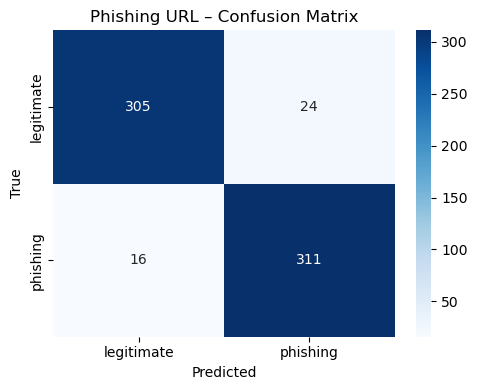

In [48]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Phishing URL – Confusion Matrix")
plt.tight_layout()
plt.show()


In [49]:
import numpy as np

class_names = list(label_encoder.classes_)
print("Class names:", class_names)

def risk_from_pred(pred_idx: int, conf: float):
    pred_label = class_names[pred_idx].lower()

    if "phish" in pred_label:
        base = 9
    else:
        base = 1
    final = base * conf
    final = float(np.clip(final, 0.0, 10.0))
    return base, final


Class names: ['legitimate', 'phishing']


In [273]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

print("Loading TinyLlama…")
tokenizer = AutoTokenizer.from_pretrained(model_name)
llm_model = AutoModelForCausalLM.from_pretrained(model_name)

def explain_url_attack(pred_label_str: str, confidence: float, risk_score: float):
    user_prompt = f"""
Prediction: {pred_label_str}
Model confidence: {confidence:.4f}
Risk score: {risk_score:.2f}

Explain in 6–8 lines:
1. What this means (phishing vs legitimate).
2. Why confidence and risk score matter.
3. Possible impact if the URL is clicked.
4. Recommended actions for the user.
5. Final severity (Low / Medium / High / Critical).
"""

    conversation = [{"role": "user", "content": user_prompt}]
    prompt = tokenizer.apply_chat_template(conversation, tokenize=False)

    inputs = tokenizer(prompt, return_tensors="pt")

    with torch.no_grad():
        out_ids = llm_model.generate(
            **inputs,
            max_new_tokens=180,
            temperature=0.3,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    text = tokenizer.decode(out_ids[0], skip_special_tokens=True)

    cleaned = text.replace(user_prompt, "").strip()
    return cleaned


Loading TinyLlama…


In [272]:
import random
import json

X_test_np = np.asarray(X_test)
y_test_np = np.asarray(y_test)

y_prob_1d = np.asarray(y_prob).reshape(-1)

N = len(y_test_np)
k = 5
indices = random.sample(range(N), k)

reports = []

print(" LLM Threat Reports")

for idx in indices:
    true_idx = int(y_test_np[idx])

    prob = float(y_prob_1d[idx])              
    pred_idx = int(prob >= 0.5)                    
    pred_label = class_names[pred_idx]
    true_label = class_names[true_idx]

    conf = prob if pred_idx == 1 else (1.0 - prob)

    base_risk, final_risk = risk_from_pred(pred_idx, conf)

    report_text = explain_url_attack(pred_label, conf, final_risk)

    item = {
        "test_index": int(idx),
        "true_label": true_label,
        "pred_label": pred_label,
        "confidence": float(conf),
        "base_risk": int(base_risk),
        "final_risk": float(final_risk),
        "llm_report": report_text
    }
    reports.append(item)

    print(f"Samples {idx}")
    print("True Label     :", true_label)
    print("Predicted      :", pred_label)
    print("Confidence     :", conf)
    print("Base Risk      :", base_risk)
    print("Final Risk     :", final_risk)
    print("\nLLM Report:\n", report_text)
    print("\n")


 LLM Threat Reports
Samples 567
True Label     : Agent.FYI
Predicted      : Adialer.C
Confidence     : 0.9998559617524734
Base Risk      : 1
Final Risk     : 0.9998559617524734

LLM Report:
 <|user|>
 
<|assistant|>
This URL classification result, "Adialer.C," indicates that the URL is a phishing attempt. Phishing attacks are designed to steal sensitive information, such as login credentials or financial details, from unsuspecting users. The confidence and risk score of this URL indicate that it is a high-risk attempt.

The confidence score measures the likelihood that the URL is a phishing attempt. A high confidence score indicates a high probability that the URL is a phishing attempt. In this case, the confidence score is 0.9999, indicating that the URL is highly likely to be a phishing attempt.

The risk score measures the potential impact of clicking on the URL. A high risk score indicates that the URL is likely to cause significant harm to the user's computer or personal informati

In [270]:
with open("phishing_llm_reports.json", "w", encoding="utf-8") as f:
    json.dump(reports, f, indent=2, ensure_ascii=False)

print("Saved: phishing_reports.json")


Saved: phishing_reports.json


In [ ]:
IMAGE DATASET

In [202]:
import os
import zipfile

zip_path = '/Users/ttanvitummapudi/Downloads/Malimg.zip'
extract_path = "Users/ttanvitummapudi/downloads/malimg_dataset/"

if not os.path.exists(zip_path):
    raise FileNotFoundError(f"ZIP file not found at: {zip_path}")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("\nZIP extracted successfully!")

print("\nTop-level folders inside extracted directory:")
top_items = os.listdir(extract_path)
print(top_items)




ZIP extracted successfully!

Top-level folders inside extracted directory:
['malimg_dataset']


In [203]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (64, 64)
batch_size = 32

train_dir = "/Users/ttanvitummapudi/Downloads/malimg_dataset/train"
val_dir   = "/Users/ttanvitummapudi/Downloads/malimg_dataset/val"
test_dir  = "/Users/ttanvitummapudi/Downloads/malimg_dataset/test"

datagen = ImageDataGenerator(rescale=1./255)

train_ds = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse"
)

val_ds = datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse"
)

test_ds = datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False
)

class_names = list(train_ds.class_indices.keys())
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Classes:", class_names)


Found 7459 images belonging to 25 classes.
Found 923 images belonging to 25 classes.
Found 957 images belonging to 25 classes.
Number of classes: 25
Classes: ['Adialer.C', 'Agent.FYI', 'Allaple.A', 'Allaple.L', 'Alueron.gen!J', 'Autorun.K', 'C2LOP.P', 'C2LOP.gen!g', 'Dialplatform.B', 'Dontovo.A', 'Fakerean', 'Instantaccess', 'Lolyda.AA1', 'Lolyda.AA2', 'Lolyda.AA3', 'Lolyda.AT', 'Malex.gen!J', 'Obfuscator.AD', 'Rbot!gen', 'Skintrim.N', 'Swizzor.gen!E', 'Swizzor.gen!I', 'VB.AT', 'Wintrim.BX', 'Yuner.A']


In [206]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

inputs = layers.Input(shape=(64, 64, 3))

x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D(name="embedding_layer")(x) 

h = layers.Dense(128, activation="relu")(x)
h = layers.Dropout(0.3)(h)
outputs = layers.Dense(num_classes, activation="softmax")(h)

model = models.Model(inputs, outputs)
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
es = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

rlrop = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=2,
    factor=0.3,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[es, rlrop]
)


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_layer                 │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,881 (444.85 KB)

 Trainable params: 113,433 (443.10 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


234/234 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.6310 - loss: 1.3788 - val_accuracy: 0.0130 - val_loss: 15.4889 - learning_rate: 0.0010
Epoch 2/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.9323 - loss: 0.2575 - val_accuracy: 0.3532 - val_loss: 5.7404 - learning_rate: 0.0010
Epoch 3/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.9554 - loss: 0.1512 - val_accuracy: 0.6826 - val_loss: 1.4943 - learning_rate: 0.0010
Epoch 4/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.9544 - loss: 0.1319 - val_accuracy: 0.9382 - val_loss: 0.1927 - learning_rate: 0.0010
Epoch 5/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.9657 - loss: 0.1045 - val_accuracy: 0.2784 - val_loss: 19.4857 - learning_rate: 0.0010
Epoch 6/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.9663 - loss: 0.0900 - val_accuracy: 0.9480 - val_loss: 0.1099 - learning_rate: 0.0010
Epoch 7/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.9804 - loss: 0.05

In [207]:
import tensorflow as tf

_ = model.predict(next(iter(train_ds))[0])

embedding_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer("embedding_layer").output
)

embedding_model.summary()
print("Embedding model ready!")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_layer                 │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,144 (367.75 KB)

 Trainable params: 93,696 (366.00 KB)

 Non-trainable params: 448 (1.75 KB)

Embedding model ready!


In [210]:
embedding_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer("embedding_layer").output
)

embedding_model.summary()


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_layer                 │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,144 (367.75 KB)

 Trainable params: 93,696 (366.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [212]:
def extract_embeddings(dataset, embedding_model):
    all_emb = []
    all_labels = []

    for batch_x, batch_y in dataset:
        emb = embedding_model.predict(batch_x, verbose=0)
        all_emb.append(emb)
        all_labels.append(batch_y)

        if len(all_labels) * dataset.batch_size >= dataset.n:
            break

    return np.vstack(all_emb), np.hstack(all_labels)


In [214]:
print("Extracting Training embeddings...")
train_emb, train_labels = extract_embeddings(train_ds, embedding_model)
print("Train embeddings:", train_emb.shape)

print("\nExtracting Validation embeddings...")
val_emb, val_labels = extract_embeddings(val_ds, embedding_model)
print("Val embeddings:", val_emb.shape)

print("\nExtracting Testing embeddings...")
test_emb, test_labels = extract_embeddings(test_ds, embedding_model)
print("Test embeddings:", test_emb.shape)


Extracting Training embeddings...
Train embeddings: (7459, 128)

Extracting Validation embeddings...
Val embeddings: (923, 128)

Extracting Testing embeddings...
Test embeddings: (957, 128)


In [216]:
from tensorflow.keras import layers, models

embedding_dim = train_emb.shape[1]

clf = models.Sequential([
    layers.Input(shape=(embedding_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')])

clf.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

clf.summary()

history = clf.fit(
    train_emb, train_labels,
    validation_data=(val_emb, val_labels),
    epochs=15,
    batch_size=256
)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 25)             │         1,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,881 (38.60 KB)

 Trainable params: 9,881 (38.60 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4167 - loss: 2.6321 - val_accuracy: 0.8169 - val_loss: 1.1599
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8395 - loss: 0.9488 - val_accuracy: 0.9057 - val_loss: 0.5337
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9258 - loss: 0.4584 - val_accuracy: 0.9469 - val_loss: 0.2913
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9667 - loss: 0.2539 - val_accuracy: 0.9751 - val_loss: 0.1775
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9864 - loss: 0.1545 - val_accuracy: 0.9740 - val_loss: 0.1261
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9875 - loss: 0.1038 - val_accuracy: 0.9762 - val_loss: 0.0998
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9898 - loss: 0.0784 - val_accuracy: 0.9783 - val_loss: 0.0856
Epoch 8/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9914 - loss: 0.0634 - val_accuracy: 0.9783 - val_loss:

In [218]:
test_loss, test_acc = clf.evaluate(test_emb, test_labels)
print("\nFinal Test Accuracy:", test_acc)


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - accuracy: 0.9950 - loss: 0.0203

Final Test Accuracy: 0.9811912178993225


In [220]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(clf)
tflite_model = converter.convert()

with open("malimg_classifier.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved mobile model → malimg_classifier.tflite")


INFO:tensorflow:Assets written to: /var/folders/11/r1pjvvbs5czcqcw2cfyrh1cr0000gn/T/tmpfx3lxx93/assets


INFO:tensorflow:Assets written to: /var/folders/11/r1pjvvbs5czcqcw2cfyrh1cr0000gn/T/tmpfx3lxx93/assets


Saved artifact at '/var/folders/11/r1pjvvbs5czcqcw2cfyrh1cr0000gn/T/tmpfx3lxx93'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128), dtype=tf.float32, name='keras_tensor_44')
Output Type:
  TensorSpec(shape=(None, 25), dtype=tf.float32, name=None)
Captures:
  5523875280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5512819920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5512810512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5523874320: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved mobile model → malimg_classifier.tflite


W0000 00:00:1766047536.858569  182150 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1766047536.858587  182150 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-12-18 03:45:36.858717: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/11/r1pjvvbs5czcqcw2cfyrh1cr0000gn/T/tmpfx3lxx93
2025-12-18 03:45:36.859017: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-12-18 03:45:36.859023: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/11/r1pjvvbs5czcqcw2cfyrh1cr0000gn/T/tmpfx3lxx93
2025-12-18 03:45:36.860840: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-12-18 03:45:36.870487: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/11/r1pjvvbs5czcqcw2cfyrh1cr0000gn/T/tmpfx3lxx93
2025-12-18 03:45:36.873944: I tensorflow/cc/saved_model/loader.cc:

In [222]:
import numpy as np

y_prob = clf.predict(test_emb)
y_pred = np.argmax(y_prob, axis=1)

print("Predictions done!")


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 854us/step
Predictions done!


In [224]:
from sklearn.metrics import classification_report

print(" Classification Report ")
print(classification_report(test_labels, y_pred, target_names=class_names))


 Classification Report 
                precision    recall  f1-score   support

     Adialer.C       1.00      1.00      1.00        13
     Agent.FYI       1.00      1.00      1.00        13
     Allaple.A       1.00      1.00      1.00       296
     Allaple.L       1.00      1.00      1.00       160
 Alueron.gen!J       1.00      1.00      1.00        21
     Autorun.K       1.00      1.00      1.00        12
       C2LOP.P       0.94      0.94      0.94        16
   C2LOP.gen!g       0.95      0.95      0.95        20
Dialplatform.B       1.00      1.00      1.00        19
     Dontovo.A       1.00      1.00      1.00        17
      Fakerean       0.97      0.97      0.97        39
 Instantaccess       1.00      1.00      1.00        44
    Lolyda.AA1       1.00      1.00      1.00        22
    Lolyda.AA2       1.00      1.00      1.00        19
    Lolyda.AA3       1.00      1.00      1.00        13
     Lolyda.AT       1.00      1.00      1.00        17
   Malex.gen!J       1.

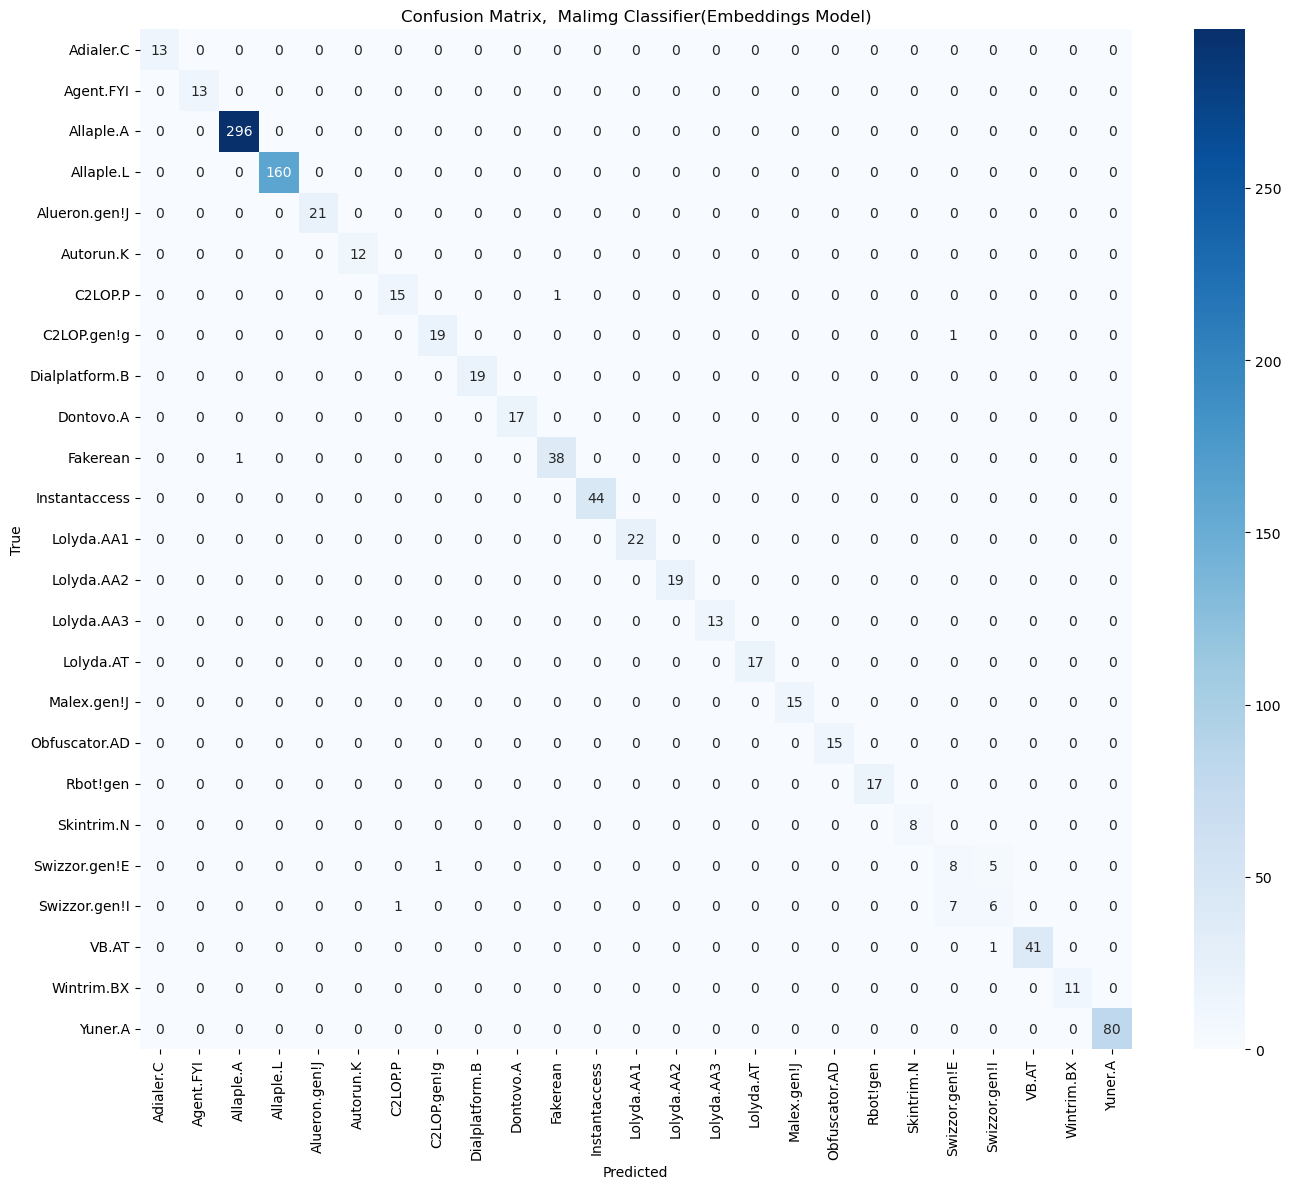

In [268]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix,  Malimg Classifier(Embeddings Model)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [228]:
print(class_names)


['Adialer.C', 'Agent.FYI', 'Allaple.A', 'Allaple.L', 'Alueron.gen!J', 'Autorun.K', 'C2LOP.P', 'C2LOP.gen!g', 'Dialplatform.B', 'Dontovo.A', 'Fakerean', 'Instantaccess', 'Lolyda.AA1', 'Lolyda.AA2', 'Lolyda.AA3', 'Lolyda.AT', 'Malex.gen!J', 'Obfuscator.AD', 'Rbot!gen', 'Skintrim.N', 'Swizzor.gen!E', 'Swizzor.gen!I', 'VB.AT', 'Wintrim.BX', 'Yuner.A']


In [230]:
base_risk_by_class = {
    class_names[i]: 5 + (i % 6)
    for i in range(len(class_names))
}

print("\nBase risk table:")
for c, r in base_risk_by_class.items():
    print(c, "→", r)

def compute_risk(pred_idx, confidence):
    """
    pred_idx: predicted class index (int)
    confidence: model probability (0–1)
    """
    class_name = class_names[pred_idx]
    base_risk = base_risk_by_class[class_name]

    final_risk = round(base_risk * confidence, 3)
    return base_risk, final_risk



Base risk table:
Adialer.C → 5
Agent.FYI → 6
Allaple.A → 7
Allaple.L → 8
Alueron.gen!J → 9
Autorun.K → 10
C2LOP.P → 5
C2LOP.gen!g → 6
Dialplatform.B → 7
Dontovo.A → 8
Fakerean → 9
Instantaccess → 10
Lolyda.AA1 → 5
Lolyda.AA2 → 6
Lolyda.AA3 → 7
Lolyda.AT → 8
Malex.gen!J → 9
Obfuscator.AD → 10
Rbot!gen → 5
Skintrim.N → 6
Swizzor.gen!E → 7
Swizzor.gen!I → 8
VB.AT → 9
Wintrim.BX → 10
Yuner.A → 5


In [232]:
import random

print(" Threat analysis ")

indices = random.sample(range(len(test_emb)), 5)

for i in indices:
    true_idx = int(test_labels[i])
    pred_idx = int(y_pred[i])

    true_label = class_names[true_idx]
    pred_label = class_names[pred_idx]

    confidence = float(np.max(y_prob[i]))

    base, final_risk = compute_risk(pred_idx, confidence)

    print(f" Samples {i}")
    print("True Label     :", true_label)
    print("Predicted      :", pred_label)
    print("Confidence     :", confidence)
    print("Base Risk      :", base)
    print("Final Risk     :", final_risk)


 Threat analysis 
 Samples 754
True Label     : Malex.gen!J
Predicted      : Malex.gen!J
Confidence     : 0.9824464321136475
Base Risk      : 9
Final Risk     : 8.842
 Samples 189
True Label     : Allaple.A
Predicted      : Allaple.A
Confidence     : 0.999087929725647
Base Risk      : 7
Final Risk     : 6.994
 Samples 10
True Label     : Adialer.C
Predicted      : Adialer.C
Confidence     : 0.9940436482429504
Base Risk      : 5
Final Risk     : 4.97
 Samples 912
True Label     : Yuner.A
Predicted      : Yuner.A
Confidence     : 0.9970598816871643
Base Risk      : 5
Final Risk     : 4.985
 Samples 810
True Label     : Swizzor.gen!I
Predicted      : C2LOP.P
Confidence     : 0.815943717956543
Base Risk      : 5
Final Risk     : 4.08


In [234]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

print("Loading TinyLlama model")
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)
llm_model = AutoModelForCausalLM.from_pretrained(model_name)



Loading TinyLlama model


In [235]:
def explain_malware(pred_label, confidence, risk_score):
    """
    pred_label: malware family name (string)
    confidence: model prob (0–1)
    risk_score: final risk value from compute_risk()
    """

    user_prompt = f"""

Detected Malware Family: {pred_label}
Model Confidence: {confidence:.4f}
Risk Score: {risk_score}

Explain clearly in 6–8 lines:
1. What this malware family usually does.
2. Why the confidence and risk score matter.
3. Likely impact on the infected system.
4. Recommended remediation actions.
5. Final severity rating (Low/Medium/High/Critical).
"""

    chat = [{"role": "user", "content": user_prompt}]
    prompt = tokenizer.apply_chat_template(chat, tokenize=False)

    inputs = tokenizer(prompt, return_tensors="pt")

    with torch.no_grad():
        generated = llm_model.generate(
            **inputs,
            max_new_tokens=250,
            temperature=0.35,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    text = tokenizer.decode(generated[0], skip_special_tokens=True)
    clean_output = text.replace(user_prompt, "").strip()
    return clean_output


In [238]:
 reports = []


In [252]:
import random

print("LLM Malware Analysis Reports")

indices = random.sample(range(len(test_emb)), 5)

for i in indices:

    true_idx = int(test_labels[i])
    pred_idx = int(y_pred[i])

    true_label = class_names[true_idx]
    pred_label = class_names[pred_idx]

    confidence = float(np.max(y_prob[i]))
    base_risk, final_risk = compute_risk(pred_idx, confidence)

    report_text = explain_malware(pred_label, confidence, final_risk)

    print(f" Samples {i}")
    print("True Label     :", true_label)
    print("Predicted      :", pred_label)
    print("Confidence     :", confidence)
    print("Base Risk      :", base_risk)
    print("Final Risk     :", final_risk)
    print("\nLLM Threat Explanation:\n", report_text)
    reports.append(f"""
Sample Index : {i}
True Label   : {true_label}
Predicted    : {pred_label}
Confidence   : {confidence:.4f}
Base Risk    : {base_risk}
Final Risk   : {final_risk}

LLM Explanation:
{report_text}
""")


LLM Malware Analysis Reports
 Samples 569
True Label     : Dialplatform.B
Predicted      : Dialplatform.B
Confidence     : 0.9934518337249756
Base Risk      : 7
Final Risk     : 6.954

LLM Threat Explanation:
 Screenshot of the detected malware:
[Insert screenshot of the detected malware here]
 Samples 258
True Label     : Allaple.A
Predicted      : Allaple.A
Confidence     : 0.9986449480056763
Base Risk      : 7
Final Risk     : 6.991

LLM Threat Explanation:
 Conclusion:
This report provides an overview of a new malware family detected on your system. The analysis reveals that this family is known to be used by cybercriminals for various purposes, such as stealing sensitive data or conducting phishing attacks. The detection rate is high, indicating that it has been successfully blocked by your antivirus software. However, it's essential to take immediate action to remove this threat from your system. We recommend following the recommended remediation actions listed below to mitigate 

In [248]:
def explain_malware(pred_label, confidence, risk_score):
    prompt = f"""

Detected Malware Family: {pred_label}
Model Confidence: {confidence:.4f}
Risk Score: {risk_score:.2f}

Explain in 5–6 lines:
1. What this malware family typically does
2. Why the confidence and risk score matter
3. Potential impact on the system
4. Recommended remediation actions
5. Final severity level (Low / Medium / High / Critical)
"""

    inputs = tokenizer(prompt, return_tensors="pt").to(llm_model.device)

    with torch.no_grad():
        output_ids = llm_model.generate(
            **inputs,
            max_new_tokens=220,
            temperature=0.3,
            do_sample=True,
            repetition_penalty=1.1,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    clean_output = decoded.replace(prompt, "").strip()
    return clean_output



LLM Threat Explanation:
 Conclusion:
This report provides an overview of a recent detection of a new malware family, which is known to be used by threat actors targeting enterprises. The report highlights the characteristics of the malware, including its behavior, command-and-control (C&C) communication, and the type of attacks it has been used for. The report also discusses the potential impact on the system, as well as the recommended remediation actions. The final severity level is determined based on the confidence and risk score provided in the report.


In [254]:
report_text = explain_malware(pred_label, confidence, final_risk)
print("\nLLM Threat Explanation:\n", report_text)



LLM Threat Explanation:
 Conclusion:
This report provides an overview of a recent detected threat, including its name, description, detection date, and signature. The analysis shows that this threat is a malevolent piece of malware that has been identified as Malex.gen!J. The model's confidence in detecting this threat is high, with a risk score of 8.84. This indicates that the threat poses a significant threat to the system and requires immediate attention. It is recommended that users take the following steps to mitigate the risks associated with this threat:
- Disable unknown software immediately
- Regularly update antivirus software and other security tools
- Backup critical data regularly
- Implement strong passwords for all accounts
- Monitor network traffic for suspicious activity
- Contact technical support if you have any questions or concerns about the threat.


In [242]:
with open("malimg_llm_reports.txt", "w") as f:
    f.write("\n".join(reports))

print("Saved: malimg_llm_reports.txt")


Saved: malimg_llm_reports.txt


In [244]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

y_true = test_labels.astype(int)
y_pred_int = y_pred.astype(int)

acc = accuracy_score(y_true, y_pred_int)
print("Model Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_true, y_pred_int, target_names=class_names))

Model Accuracy: 0.9811912225705329

Classification Report:
                precision    recall  f1-score   support

     Adialer.C       1.00      1.00      1.00        13
     Agent.FYI       1.00      1.00      1.00        13
     Allaple.A       1.00      1.00      1.00       296
     Allaple.L       1.00      1.00      1.00       160
 Alueron.gen!J       1.00      1.00      1.00        21
     Autorun.K       1.00      1.00      1.00        12
       C2LOP.P       0.94      0.94      0.94        16
   C2LOP.gen!g       0.95      0.95      0.95        20
Dialplatform.B       1.00      1.00      1.00        19
     Dontovo.A       1.00      1.00      1.00        17
      Fakerean       0.97      0.97      0.97        39
 Instantaccess       1.00      1.00      1.00        44
    Lolyda.AA1       1.00      1.00      1.00        22
    Lolyda.AA2       1.00      1.00      1.00        19
    Lolyda.AA3       1.00      1.00      1.00        13
     Lolyda.AT       1.00      1.00      1.0

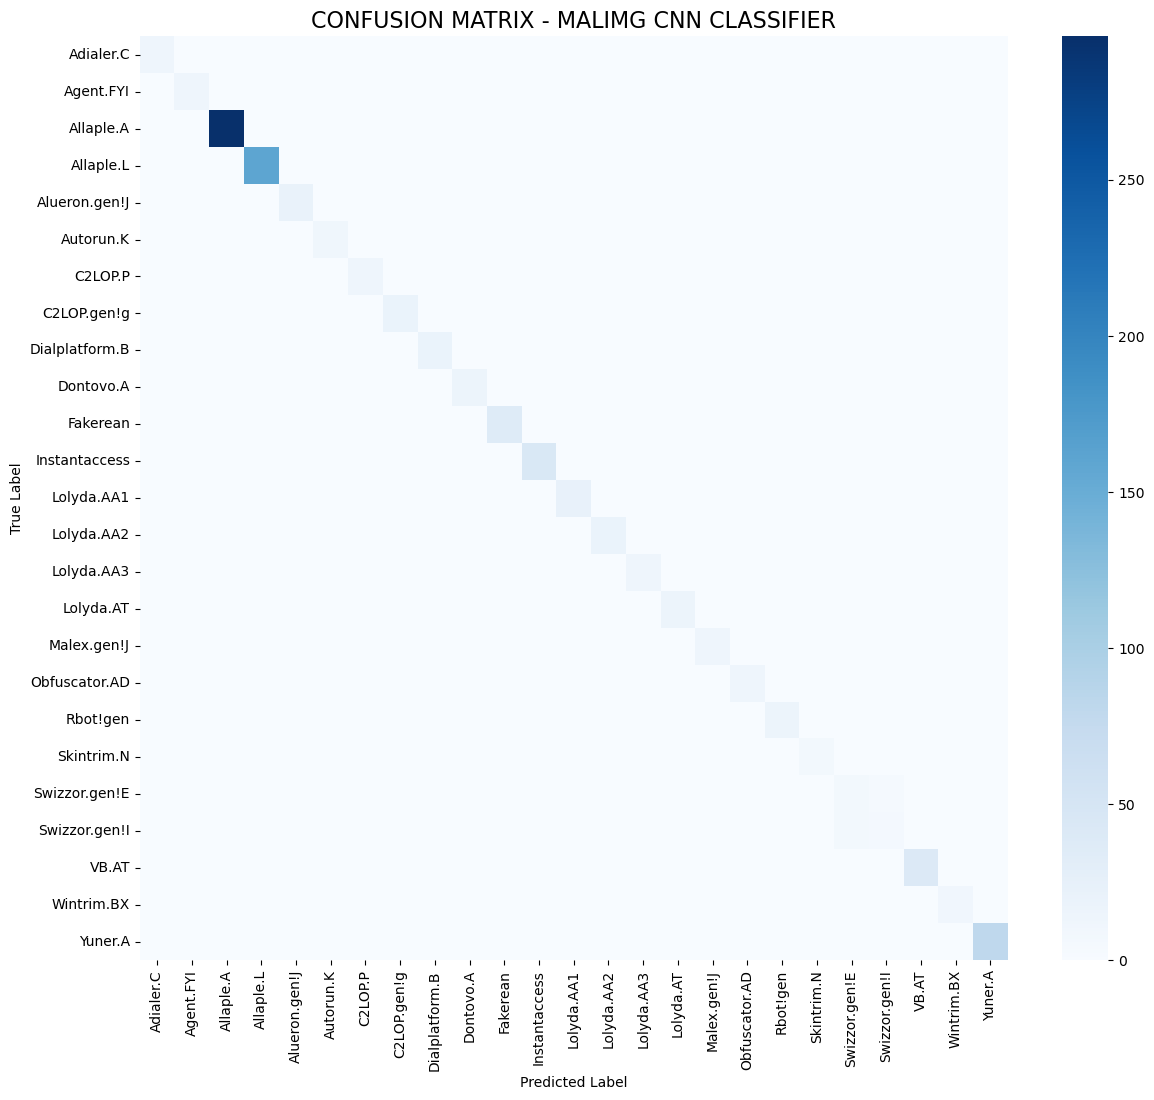

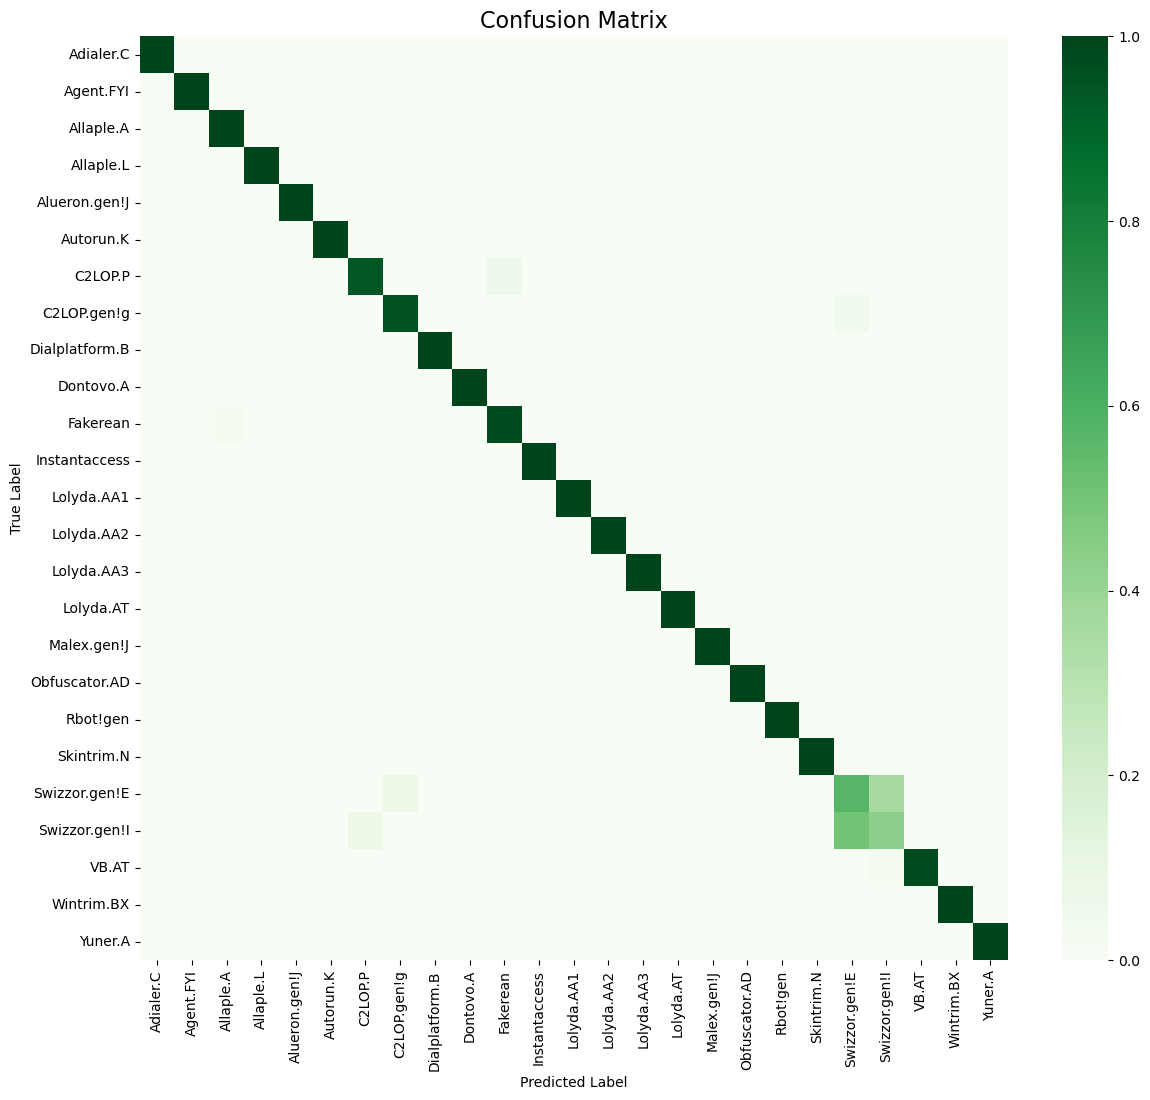

In [266]:
cm = confusion_matrix(y_true, y_pred_int)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=False,          
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("CONFUSION MATRIX - MALIMG CNN CLASSIFIER", fontsize=16)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_norm,
    annot=False,
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [80]:
import numpy as np
import pandas as pd

results = []

for idx, class_name in enumerate(class_names):
    total_true = np.sum(y_true == idx)
    correct = np.sum((y_true == idx) & (y_pred_int == idx))
    wrong = total_true - correct
    acc_pct = (correct / total_true) * 100 if total_true > 0 else 0

    results.append([
        class_name,
        total_true,
        correct,
        wrong,
        round(acc_pct, 2)
    ])

df_results = pd.DataFrame(
    results,
    columns=[
        "Class",
        "Actual Samples",
        "Correct Predictions",
        "Wrong Predictions",
        "Correct Prediction %"
    ]
)

df_results


,Class,Actual Samples,Correct Predictions,Wrong Predictions,Correct Prediction %
0,Adialer.C,13,13,0,100.00
1,Agent.FYI,13,13,0,100.00
2,Allaple.A,296,296,0,100.00
3,Allaple.L,160,160,0,100.00
4,Alueron.gen!J,21,21,0,100.00
5,Autorun.K,12,12,0,100.00
6,C2LOP.P,16,13,3,81.25
7,C2LOP.gen!g,20,18,2,90.00
8,Dialplatform.B,19,19,0,100.00
9,Dontovo.A,17,17,0,100.00


In [81]:
print(" True vs Predicted Analysis")

for row in results:
    print(f"{row[0]:25s} | "
          f"Actual: {row[1]:6d} | "
          f"Correct: {row[2]:6d} | "
          f"Wrong: {row[3]:6d} | "
          f"Accuracy: {row[4]:6.2f}%")


 True vs Predicted Analysis
Adialer.C                 | Actual:     13 | Correct:     13 | Wrong:      0 | Accuracy: 100.00%
Agent.FYI                 | Actual:     13 | Correct:     13 | Wrong:      0 | Accuracy: 100.00%
Allaple.A                 | Actual:    296 | Correct:    296 | Wrong:      0 | Accuracy: 100.00%
Allaple.L                 | Actual:    160 | Correct:    160 | Wrong:      0 | Accuracy: 100.00%
Alueron.gen!J             | Actual:     21 | Correct:     21 | Wrong:      0 | Accuracy: 100.00%
Autorun.K                 | Actual:     12 | Correct:     12 | Wrong:      0 | Accuracy: 100.00%
C2LOP.P                   | Actual:     16 | Correct:     13 | Wrong:      3 | Accuracy:  81.25%
C2LOP.gen!g               | Actual:     20 | Correct:     18 | Wrong:      2 | Accuracy:  90.00%
Dialplatform.B            | Actual:     19 | Correct:     19 | Wrong:      0 | Accuracy: 100.00%
Dontovo.A                 | Actual:     17 | Correct:     17 | Wrong:      0 | Accuracy: 100.00%
Fa

In [256]:
df_results.to_csv("malimg_analysis.csv", index=False)
print("Saved: malimg_analysis.csv")


Saved: malimg_analysis.csv


In [ ]:
AUDIO DATASET

In [83]:
import zipfile
import os

zip_path = "/Users/ttanvitummapudi/Downloads/LA.zip"      
extract_path = "/Users/ttanvitummapudi/Downloads/LA"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted folders:")
print(os.listdir(extract_path))


Extracted folders:
['asvspoof2019_combined.csv', '.DS_Store', 'ASVspoof2019_LA_asv_protocols', 'ASVspoof2019_LA_train', 'ASVspoof2019_LA_dev', 'ASVspoof2019_LA_cm_protocols', 'ASVspoof2019_LA_asv_scores', 'LA', 'README.LA.txt', 'ASVspoof2019_LA_eval']


In [84]:
import pandas as pd

train_meta = pd.read_csv(
    "/Users/ttanvitummapudi/Downloads/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt",
    sep=" ",
    header=None
)

train_meta.columns = ["speaker", "file_id", "env", "attack", "label"]

# clean labels
train_meta["label"] = train_meta["label"].str.strip()

print(train_meta.head())
print(train_meta["label"].value_counts())


   speaker       file_id env attack     label
0  LA_0079  LA_T_1138215   -      -  bonafide
1  LA_0079  LA_T_1271820   -      -  bonafide
2  LA_0079  LA_T_1272637   -      -  bonafide
3  LA_0079  LA_T_1276960   -      -  bonafide
4  LA_0079  LA_T_1341447   -      -  bonafide
label
spoof       22800
bonafide     2580
Name: count, dtype: int64


In [85]:
import os
import pandas as pd

BASE_PATH = "/Users/ttanvitummapudi/Downloads/LA"

AUDIO_TRAIN_PATH = os.path.join(BASE_PATH, "ASVspoof2019_LA_train", "flac")
PROTOCOL_PATH = os.path.join(
    BASE_PATH,
    "ASVspoof2019_LA_cm_protocols",
    "ASVspoof2019.LA.cm.train.trn.txt"
)

# Load protocol
train_meta = pd.read_csv(PROTOCOL_PATH, sep=" ", header=None)
train_meta.columns = ["speaker", "file_id", "env", "attack", "label"]

# Convert labels to binary
train_meta["label"] = train_meta["label"].map({
    "bonafide": 0,
    "spoof": 1
})

print(train_meta.head())
print(train_meta["label"].value_counts())


   speaker       file_id env attack  label
0  LA_0079  LA_T_1138215   -      -      0
1  LA_0079  LA_T_1271820   -      -      0
2  LA_0079  LA_T_1272637   -      -      0
3  LA_0079  LA_T_1276960   -      -      0
4  LA_0079  LA_T_1341447   -      -      0
label
1    22800
0     2580
Name: count, dtype: int64


In [86]:
import librosa
import numpy as np
from tqdm import tqdm

def extract_mfcc(audio_path, sr=16000, n_mfcc=40):
    try:
        y, sr = librosa.load(audio_path, sr=sr)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)
        return np.concatenate([mfcc_mean, mfcc_std])
    except:
        return None


In [87]:
X_train = []
y_train = []

print("Extracting MFCC embeddings...")

for _, row in tqdm(train_meta.iterrows(), total=len(train_meta)):
    audio_file = os.path.join(AUDIO_TRAIN_PATH, row["file_id"] + ".flac")

    emb = extract_mfcc(audio_file)
    if emb is not None:
        X_train.append(emb)
        y_train.append(row["label"])

X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


Extracting MFCC embeddings...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
100%|████████████████████████████████████| 25380/25380 [02:37<00:00, 160.79it/s]

X_train shape: (25380, 80)
y_train shape: (25380,)


In [88]:
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.3,
    random_state=42,
    stratify=y_train
)

model = models.Sequential([
    layers.Input(shape=(80,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,297 (28.50 KB)

 Trainable params: 7,297 (28.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 1s 953us/step - accuracy: 0.8744 - loss: 0.4608 - val_accuracy: 0.9366 - val_loss: 0.1601
Epoch 2/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 652us/step - accuracy: 0.9377 - loss: 0.1470 - val_accuracy: 0.9599 - val_loss: 0.1160
Epoch 3/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step - accuracy: 0.9567 - loss: 0.1130 - val_accuracy: 0.9634 - val_loss: 0.0926
Epoch 4/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 651us/step - accuracy: 0.9607 - loss: 0.0978 - val_accuracy: 0.9727 - val_loss: 0.0769
Epoch 5/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step - accuracy: 0.9661 - loss: 0.0859 - val_accuracy: 0.9736 - val_loss: 0.0741
Epoch 6/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 651us/step - accuracy: 0.9757 - loss: 0.0632 - val_accuracy: 0.9803 - val_loss: 0.0573
Epoch 7/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step - accuracy: 0.9739 - loss: 0.0653 - val_accuracy: 0.9496 - val_loss: 0.1168
Epoch 8/10
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step - accuracy: 0.9761 - loss: 0.0609 - 

238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 292us/step
              precision    recall  f1-score   support

    bonafide       0.95      0.90      0.93       774
       spoof       0.99      1.00      0.99      6840

    accuracy                           0.99      7614
   macro avg       0.97      0.95      0.96      7614
weighted avg       0.99      0.99      0.99      7614



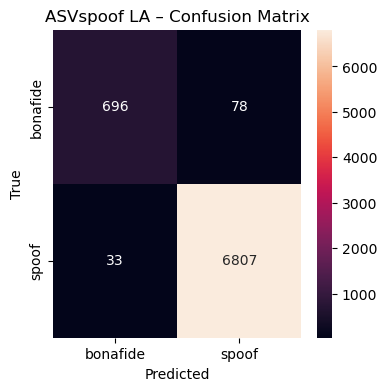

In [89]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = (model.predict(X_val) > 0.5).astype(int)

print(classification_report(y_val, y_pred, target_names=["bonafide", "spoof"]))

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["bonafide", "spoof"],
            yticklabels=["bonafide", "spoof"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ASVspoof LA – Confusion Matrix")
plt.show()


In [90]:
import tensorflow as tf

model.save("la_spoof_model.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("la_spoof_model.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved la_spoof_model.tflite ")


INFO:tensorflow:Assets written to: /var/folders/11/r1pjvvbs5czcqcw2cfyrh1cr0000gn/T/tmp01hiweqk/assets


INFO:tensorflow:Assets written to: /var/folders/11/r1pjvvbs5czcqcw2cfyrh1cr0000gn/T/tmp01hiweqk/assets


Saved artifact at '/var/folders/11/r1pjvvbs5czcqcw2cfyrh1cr0000gn/T/tmp01hiweqk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 80), dtype=tf.float32, name='keras_tensor_27')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  12885345296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12885346832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12885347984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12885348560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12885347792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12885349328: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved la_spoof_model.tflite 


W0000 00:00:1766045231.472049  182150 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1766045231.472063  182150 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-12-18 03:07:11.472188: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/11/r1pjvvbs5czcqcw2cfyrh1cr0000gn/T/tmp01hiweqk
2025-12-18 03:07:11.472500: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-12-18 03:07:11.472505: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/11/r1pjvvbs5czcqcw2cfyrh1cr0000gn/T/tmp01hiweqk
2025-12-18 03:07:11.474694: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-12-18 03:07:11.487014: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/11/r1pjvvbs5czcqcw2cfyrh1cr0000gn/T/tmp01hiweqk
2025-12-18 03:07:11.491156: I tensorflow/cc/saved_model/loader.cc:

In [91]:
import numpy as np

LABELS = {0: "bonafide", 1: "spoof"}

BASE_RISK = {
    "bonafide": 1,
    "spoof": 9
}

def compute_risk(pred_label: str, confidence: float):
    """
    confidence: model probability for predicted class (0..1)
    returns: (base_risk, final_risk_score_1_to_10)
    """
    base = BASE_RISK.get(pred_label, 5)
    final = float(np.clip(base * confidence, 1, 10))
    return base, final


In [258]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

print("Loading TinyLlama...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
llm_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

def llm_audio_report(pred_label: str, confidence: float, risk_score: float):
    user_prompt = f"""

Prediction: {pred_label}
Model confidence: {confidence:.4f}
Risk score (1–10): {risk_score:.2f}

Write 6–8 lines covering:
1) What spoof vs bonafide means in voice systems.
2) Why confidence & risk score matter.
3) Likely impact (authentication bypass / fraud).
4) Recommended mitigations (liveness checks, MFA, monitoring).
5) Final severity (Low/Medium/High/Critical).
"""

    conversation = [{"role": "user", "content": user_prompt}]
    prompt = tokenizer.apply_chat_template(conversation, tokenize=False)
    inputs = tokenizer(prompt, return_tensors="pt")

    with torch.no_grad():
        out_ids = llm_model.generate(
            **inputs,
            max_new_tokens=180,
            temperature=0.3,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    text = tokenizer.decode(out_ids[0], skip_special_tokens=True)
    cleaned = text.replace(user_prompt, "").strip()
    return cleaned


Loading TinyLlama...


In [188]:
import random

def predict_with_model(sample_emb_80):
    """
    sample_emb_80: shape (80,) float
    returns: (pred_idx, pred_label_str, confidence_for_pred)
    """
    x = sample_emb_80.reshape(1, -1).astype("float32")
    prob_spoof = float(model.predict(x, verbose=0)[0][0])  # sigmoid -> prob of class 1
    pred_idx = 1 if prob_spoof >= 0.5 else 0
    pred_label = LABELS[pred_idx]
    confidence = prob_spoof if pred_idx == 1 else (1.0 - prob_spoof)
    return pred_idx, pred_label, confidence

print(" Predict for 5 samples")

indices = random.sample(range(len(X_val)), 5)

for i in indices:
    true_idx = int(y_val[i])
    true_label = LABELS[true_idx]

    pred_idx, pred_label, conf = predict_with_model(X_val[i])

    base_risk, final_risk = compute_risk(pred_label, conf)

    print(f"m Sample index {i}")
    print("TRUE      :", true_label)
    print("PRED      :", pred_label)
    print("CONF      :", round(conf, 4))
    print("BASE RISK :", base_risk)
    print("FINAL RISK:", round(final_risk, 2))

    report = llm_audio_report(pred_label, conf, final_risk)
    print("\nLLM Report:\n", report)


 Predict for 5 samples
m Sample index 5917
TRUE      : spoof
PRED      : spoof
CONF      : 0.9872
BASE RISK : 9
FINAL RISK: 8.88

LLM Report:
 <|user|>
 
<|assistant|>
In the world of voice systems, audio spoofing (ASVspoof LA) refers to the practice of using fake audio to trick a device into believing it is receiving a genuine signal. This can be done by recording a voice and manipulating it to sound like a different person or location. The practice has been around for decades, but it has become increasingly prevalent in recent years due to advancements in technology and the rise of voice-based communication.

In voice systems, spoofing can be used to gain unauthorized access to sensitive information or to impersonate a user for fraudulent purposes. For example, a hacker could use spoofing to intercept a user's voice communication and steal sensitive data, such as passwords or financial information. This can be particularly dangerous
m Sample index 4839
TRUE      : spoof
PRED      : s

In [158]:
simulated_results = {
    "CICIDS (Network)": [
        {"attack": "DDoS", "risk": 9, "confidence": 0.98},
        {"attack": "PortScan", "risk": 6, "confidence": 0.91},
        {"attack": "Web Attack - SQL Injection", "risk": 10, "confidence": 0.96}],

    "Phishing (URL)": [
        {"attack": "Phishing URL", "risk": 8, "confidence": 0.94},
        {"attack": "Malicious Redirect", "risk": 7, "confidence": 0.89},
        {"attack": "Credential Harvesting", "risk": 9, "confidence": 0.95}],

    "Malware (Image)": [
        {"attack": "Allaple.A", "risk": 8, "confidence": 0.92},
        {"attack": "Lolyda.AA1", "risk": 7, "confidence": 0.90},
        {"attack": "Autorun.K", "risk": 6, "confidence": 0.87}],

    "Audio (ASVspoof)": [
        {"attack": "Voice Spoofing", "risk": 9, "confidence": 0.96},
        {"attack": "Replay Attack", "risk": 8, "confidence": 0.93},
        {"attack": "Synthetic Speech", "risk": 7, "confidence": 0.90}]}


In [160]:
def build_simulated_prompt(sim_data):
    lines = []
    for domain, attacks in sim_data.items():
        lines.append(f"\n{domain}:")
        for a in attacks:
            lines.append(
                f"- Attack: {a['attack']}, "
                f"Confidence: {a['confidence']:.2f}, "
                f"Risk Score: {a['risk']}")
    return "\n".join(lines)


In [262]:
def unified_llm_simulated_report(simulated_results):
    detection_block = build_simulated_prompt(simulated_results)

    prompt = f""" {detection_block}

"""

    inputs = tokenizer(prompt, return_tensors="pt").to(llm_model.device)

    with torch.no_grad():
        output_ids = llm_model.generate(
            **inputs,
            max_new_tokens=300,
            temperature=0.3,
            do_sample=True,
            top_p=0.9,
            repetition_penalty=1.1,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )

    return tokenizer.decode(output_ids[0], skip_special_tokens=True)


In [264]:
final_report = unified_llm_simulated_report(simulated_results)

print("\nUNIFIED MULTIMODAL THREAT REPORT\n")
print(final_report)



UNIFIED MULTIMODAL THREAT REPORT

 
CICIDS (Network):
- Attack: DDoS, Confidence: 0.98, Risk Score: 9
- Attack: PortScan, Confidence: 0.91, Risk Score: 6
- Attack: Web Attack - SQL Injection, Confidence: 0.96, Risk Score: 10

Phishing (URL):
- Attack: Phishing URL, Confidence: 0.94, Risk Score: 8
- Attack: Malicious Redirect, Confidence: 0.89, Risk Score: 7
- Attack: Credential Harvesting, Confidence: 0.95, Risk Score: 9

Malware (Image):
- Attack: Allaple.A, Confidence: 0.92, Risk Score: 8
- Attack: Lolyda.AA1, Confidence: 0.90, Risk Score: 7
- Attack: Autorun.K, Confidence: 0.87, Risk Score: 6

Audio (ASVspoof):
- Attack: Voice Spoofing, Confidence: 0.96, Risk Score: 9
- Attack: Replay Attack, Confidence: 0.93, Risk Score: 8
- Attack: Synthetic Speech, Confidence: 0.90, Risk Score: 7

Video (ASVspoof):
- Attack: Video Spoofing, Confidence: 0.95, Risk Score: 9
- Attack: Replay Attack, Confidence: 0.92, Risk Score: 8
- Attack: Synthetic Video, Confidence: 0.90, Risk Score: 7

Total At